In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [ ]:
# Package imports
import numpy as np
import copy
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import sklearn.linear_model

from utils.planar_utils import plot_decision_boundary, load_planar_dataset, load_extra_datasets
from models.nn_model import nn_model
from utils.predict import predict_nn

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [4]:
X, Y = load_planar_dataset()

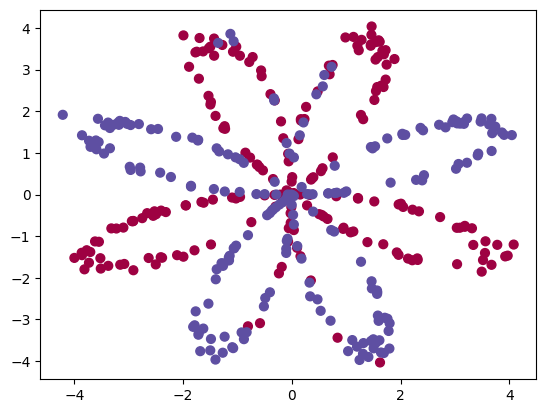

In [5]:
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral);

In [6]:
shape_X = X.shape
shape_Y = Y.shape
m = X.shape[1]

print ('The shape of X is: ' + str(shape_X))
print ('The shape of Y is: ' + str(shape_Y))

The shape of X is: (2, 400)
The shape of Y is: (1, 400)


In [7]:
clf = sklearn.linear_model.LogisticRegressionCV();
clf.fit(X.T, Y.T);

/home/iesus/Documents/deep_learning_experiments/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/iesus/Documents/deep_learning_experiments/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/home/iesus/Documents/deep_learning_experiments/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of Logis

Acc of logistic regression: 47.0 % (percentage of correctly labelled datapoints)


/tmp/ipykernel_8670/3903237102.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print (f"Acc of logistic regression: {float((np.dot(Y,LR_predictions) + np.dot(1-Y,1-LR_predictions))/float(Y.size)*100)} % (percentage of correctly labelled datapoints)")


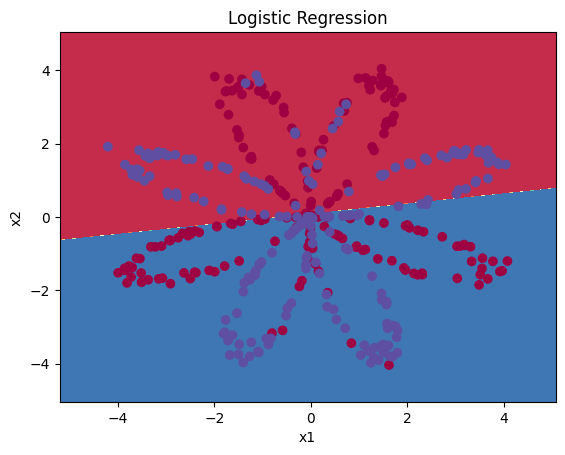

In [8]:
# Plot the decision boundary for logistic regression
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Logistic Regression")

# Print accuracy
LR_predictions = clf.predict(X.T)
print (f"Acc of logistic regression: {float((np.dot(Y,LR_predictions) + np.dot(1-Y,1-LR_predictions))/float(Y.size)*100)} % (percentage of correctly labelled datapoints)")

In [9]:
parameters = nn_model(X, Y, n_h = 4, num_iterations = 10000, print_cost=True)

Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625
Cost after iteration 2000: 0.239334
Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845
Cost after iteration 6000: 0.219094
Cost after iteration 7000: 0.220635
Cost after iteration 8000: 0.219417
Cost after iteration 9000: 0.218528


In [ ]:
# Print accuracy
predictions = predict_nn(X, parameters, hidden_activation="tanh")
print (f"Acc: {float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100)}%")

In [ ]:
plt.figure(figsize=(16, 32))
hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]

for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(6, 2, i+1)
    plt.title('Hidden Layer of size %d' % n_h)

    parameters = nn_model(X, Y, n_h, num_iterations = 5000)
    
    plot_decision_boundary(lambda x: predict_nn(x.T, parameters, hidden_activation="tanh"), X, Y)
    
    predictions = predict_nn(X, parameters, hidden_activation="tanh")
    
    accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)
    print ("Accuracy for {} hidden units: {} %".format(n_h, accuracy))

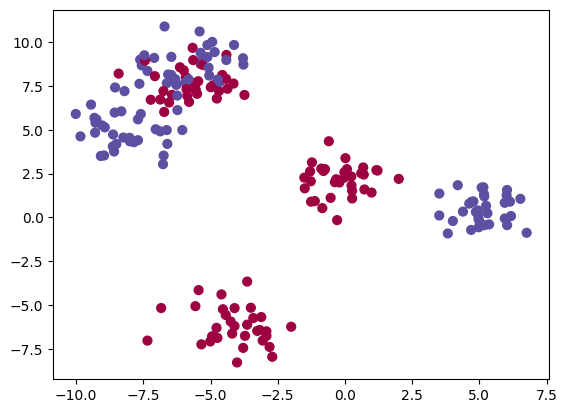

In [12]:
noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure = load_extra_datasets()

datasets = {"noisy_circles": noisy_circles, "noisy_moons": noisy_moons,
            "blobs": blobs, "gaussian_quantiles": gaussian_quantiles}

dataset = "blobs"

X, Y = datasets[dataset]
X, Y = X.T, Y.reshape(1, Y.shape[0])

# make blobs binary
if dataset == "blobs":
    Y = Y%2

# Visualize the data
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral);